# Análisis DBSCAN

Se analizará el modelo con mejores resultados, el Modelo B baseline, por medio de DBSCAN para ubicar las anomalías como ruido alrededor de los clusters formados.

In [6]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [25]:
def get_anomaly_labels(y_test):
    """
    y_test puede venir como:
    - [N] si solo hay etiqueta de clase
    - [N, 2] donde columna 0 = clase y columna 1 = tipo de defecto

    Retorna:
    0 = good
    1 = anomaly
    """
    y_test = np.asarray(y_test)

    if y_test.ndim == 1:
        return np.zeros_like(y_test, dtype=int)

    defect_code = y_test[:, 1]
    return (defect_code != 0).astype(int)


def get_class_labels(y_test):
    """
    Retorna la clase del objeto.
    """
    y_test = np.asarray(y_test)

    if y_test.ndim == 1:
        return y_test.astype(int)

    return y_test[:, 0].astype(int)


def make_pruned_test_set(
    z_test,
    y_test,
    anomaly_to_good_ratio=0.20,
    seed=42,
):
    """
    Crea un subconjunto podado del test.

    Mantiene todas las imágenes good y toma una muestra aleatoria
    de anomalías para simular un escenario con menor prevalencia
    de defectos.

    anomaly_to_good_ratio:
    - 1.0  -> misma cantidad de anomalías que good, si hay suficientes.
    - 0.5  -> una anomalía por cada dos good.
    - 0.25 -> una anomalía por cada cuatro good.
    """
    y_true = get_anomaly_labels(y_test)

    good_idx = np.where(y_true == 0)[0]
    anomaly_idx = np.where(y_true == 1)[0]

    n_good = len(good_idx)
    n_anomaly_keep = int(round(n_good * anomaly_to_good_ratio))
    n_anomaly_keep = min(n_anomaly_keep, len(anomaly_idx))

    if n_anomaly_keep <= 0:
        raise ValueError("El número de anomalías a conservar debe ser mayor que 0.")

    rng = np.random.default_rng(seed)

    sampled_anomaly_idx = rng.choice(
        anomaly_idx,
        size=n_anomaly_keep,
        replace=False,
    )

    selected_idx = np.concatenate([good_idx, sampled_anomaly_idx])
    selected_idx = rng.permutation(selected_idx)

    z_pruned = z_test[selected_idx]
    y_pruned = y_test[selected_idx]

    return z_pruned, y_pruned, selected_idx


def reduce_embeddings(z, method="pca"):
    method = method.lower()

    z_scaled = StandardScaler().fit_transform(z)

    if method == "pca":
        reducer = PCA(n_components=2, random_state=42)
        z_2d = reducer.fit_transform(z_scaled)

    elif method == "tsne":
        # t-SNE requiere que perplexity sea menor que n_samples.
        n_samples = z.shape[0]
        perplexity = min(30, max(2, n_samples // 3))
        perplexity = min(perplexity, n_samples - 1)

        reducer = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=42,
        )
        z_2d = reducer.fit_transform(z_scaled)

    else:
        raise ValueError("method debe ser 'pca' o 'tsne'")

    # DBSCAN es sensible a la escala.
    # Se escala también la representación 2D.
    z_2d_scaled = StandardScaler().fit_transform(z_2d)

    return z_2d, z_2d_scaled


def compute_binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    recall = recall_score(y_true, y_pred, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_acc = (recall + specificity) / 2

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall,
        "specificity": specificity,
        "balanced_acc": balanced_acc,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "pred_anomaly_rate": float(np.mean(y_pred == 1)),
    }

    return metrics


def evaluate_dbscan(z_2d_scaled, y_true, eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(z_2d_scaled)

    # DBSCAN marca ruido como -1. Eso se interpreta como anomalía.
    y_pred = (clusters == -1).astype(int)

    n_noise = int(np.sum(clusters == -1))
    n_clusters = len(np.unique(clusters[clusters != -1]))

    metrics = {
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_rate": n_noise / len(clusters),
    }

    metrics.update(compute_binary_metrics(y_true, y_pred))

    return metrics, clusters, y_pred


def print_baselines(y_true):
    """
    Imprime baselines triviales para interpretar si DBSCAN realmente
    aporta algo o si solo se beneficia del desbalance del test.
    """
    baselines = []

    y_all_good = np.zeros_like(y_true)
    metrics_good = compute_binary_metrics(y_true, y_all_good)
    metrics_good["baseline"] = "todo_good"
    baselines.append(metrics_good)

    y_all_anomaly = np.ones_like(y_true)
    metrics_anomaly = compute_binary_metrics(y_true, y_all_anomaly)
    metrics_anomaly["baseline"] = "todo_anomaly"
    baselines.append(metrics_anomaly)

    baseline_df = pd.DataFrame(baselines)

    columns = [
        "baseline",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "balanced_acc",
        "f1",
        "pred_anomaly_rate",
    ]

    print("\nBaselines triviales:")
    print(baseline_df[columns].to_string(index=False))

    return baseline_df


def plot_true_labels(z_2d, y_true, title):
    fig, ax = plt.subplots(figsize=(7, 6))

    scatter = ax.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=y_true,
        s=12,
        alpha=0.8,
    )

    ax.set_title(title)
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    fig.colorbar(scatter, ax=ax, label="Etiqueta real: 0=good, 1=anomaly")
    fig.tight_layout()
    plt.show()


def plot_dbscan(z_2d, clusters, title):
    fig, ax = plt.subplots(figsize=(7, 6))

    scatter = ax.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=clusters,
        s=12,
        alpha=0.8,
    )

    ax.set_title(title)
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    fig.colorbar(scatter, ax=ax, label="Cluster DBSCAN (-1=ruido)")
    fig.tight_layout()
    plt.show()


def print_confusion_and_report(y_true, y_pred):
    print("\nMatriz de confusión:")
    print(confusion_matrix(y_true, y_pred, labels=[0, 1]))

    print("\nReporte:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["good", "anomaly"],
            zero_division=0,
        )
    )


def run_analysis(
    method,
    prune=False,
    anomaly_to_good_ratio=0.25,
    seed=42,
    dataset_name=None,
):
    method = method.lower()

    data = np.load(NPZ_PATH)

    z_test = data["z_test"]
    y_test = data["y_test"]

    if prune:
        z_test, y_test, selected_idx = make_pruned_test_set(
            z_test=z_test,
            y_test=y_test,
            anomaly_to_good_ratio=anomaly_to_good_ratio,
            seed=seed,
        )

        if dataset_name is None:
            dataset_name = f"test podado ratio={anomaly_to_good_ratio}"
    else:
        selected_idx = np.arange(len(y_test))

        if dataset_name is None:
            dataset_name = "test completo"

    y_true = get_anomaly_labels(y_test)

    print(f"\n===== Análisis con {method.upper()} - {dataset_name} =====")
    print("z_test shape:", z_test.shape)
    print("y_test shape:", y_test.shape)
    print("Distribución y_true:", np.unique(y_true, return_counts=True))

    baseline_df = print_baselines(y_true)

    z_2d, z_2d_scaled = reduce_embeddings(z_test, method=method)

    eps_values = np.concatenate(
        [
            np.arange(0.01, 0.21, 0.01),
            np.arange(0.25, 1.05, 0.05),
            np.arange(1.10, 3.10, 0.10),
        ]
    )
    eps_values = np.round(eps_values, 3)

    min_samples_values = [3, 5, 10, 15, 20, 30, 50]

    results = []

    best_f1 = None
    best_f1_clusters = None
    best_f1_y_pred = None

    for eps in eps_values:
        for min_samples in min_samples_values:
            metrics, clusters, y_pred = evaluate_dbscan(
                z_2d_scaled=z_2d_scaled,
                y_true=y_true,
                eps=float(eps),
                min_samples=min_samples,
            )

            results.append(metrics)

            if best_f1 is None or metrics["f1"] > best_f1["f1"]:
                best_f1 = metrics
                best_f1_clusters = clusters
                best_f1_y_pred = y_pred

    results_df = pd.DataFrame(results)

    display_columns = [
        "eps",
        "min_samples",
        "n_clusters",
        "n_noise",
        "noise_rate",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "balanced_acc",
        "f1",
        "pred_anomaly_rate",
    ]

    results_by_f1 = results_df.sort_values("f1", ascending=False)

    print(f"\nMejores resultados por F1 con {method.upper()}:")
    print(results_by_f1[display_columns].head(10).to_string(index=False))

    results_with_noise = results_df[results_df["n_noise"] > 0].sort_values(
        "f1",
        ascending=False,
    )

    print(f"\nResultados con al menos un punto marcado como ruido ({method.upper()}):")
    if results_with_noise.empty:
        print("No hubo configuraciones con puntos de ruido.")
    else:
        print(results_with_noise[display_columns].head(10).to_string(index=False))

    # Filtro para evitar configuraciones degeneradas donde DBSCAN marca casi todo
    # como normal o casi todo como anomalía.
    filtered_df = results_df[
        (results_df["noise_rate"] >= 0.01)
        & (results_df["noise_rate"] <= 0.80)
        & (results_df["specificity"] >= 0.20)
        & (results_df["n_clusters"] >= 1)
    ].sort_values("balanced_acc", ascending=False)

    print(f"\nMejores resultados no degenerados por balanced accuracy ({method.upper()}):")
    if filtered_df.empty:
        print("No hubo configuraciones que cumplieran el filtro.")
        best_filtered = None
        best_filtered_clusters = None
        best_filtered_y_pred = None
    else:
        print(filtered_df[display_columns].head(10).to_string(index=False))

        best_filtered = filtered_df.iloc[0].to_dict()

        _, best_filtered_clusters, best_filtered_y_pred = evaluate_dbscan(
            z_2d_scaled=z_2d_scaled,
            y_true=y_true,
            eps=float(best_filtered["eps"]),
            min_samples=int(best_filtered["min_samples"]),
        )

    print("\nMejor configuración por F1:")
    print(best_f1)

    print_confusion_and_report(y_true, best_f1_y_pred)

    if best_filtered is not None:
        print("\nMejor configuración filtrada por balanced accuracy:")
        print(best_filtered)

        print_confusion_and_report(y_true, best_filtered_y_pred)

    plot_true_labels(
        z_2d,
        y_true,
        title=f"Etiquetas reales sobre embeddings reducidos con {method.upper()} - {dataset_name}",
    )

    plot_dbscan(
        z_2d,
        best_f1_clusters,
        title=f"DBSCAN sobre embeddings reducidos con {method.upper()} - {dataset_name} - mejor F1",
    )

    return {
        "method": method,
        "dataset_name": dataset_name,
        "prune": prune,
        "anomaly_to_good_ratio": anomaly_to_good_ratio if prune else None,
        "selected_idx": selected_idx,
        "baseline_df": baseline_df,
        "results_df": results_by_f1,
        "filtered_df": filtered_df,
        "best_f1": best_f1,
        "best_filtered": best_filtered,
        "z_2d": z_2d,
        "clusters": best_f1_clusters,
        "y_true": y_true,
        "y_pred": best_f1_y_pred,
    }

In [26]:
NPZ_PATH = "/content/drive/MyDrive/Proyecto2/cache/anomaly_evaluation/evaluation_outputs.npz"

In [27]:
data = np.load(NPZ_PATH)

print("Keys:", data.files)
print("z_test shape:", data["z_test"].shape)
print("y_test shape:", data["y_test"].shape)

y_true = get_anomaly_labels(data["y_test"])
print("Distribución y_true:", np.unique(y_true, return_counts=True))

Keys: ['scores', 'y_pred', 'y_test', 'z_test']
z_test shape: (1165, 128)
y_test shape: (1165, 2)
Distribución y_true: (array([0, 1]), array([344, 821]))



===== Análisis con PCA - test completo =====
z_test shape: (1165, 128)
y_test shape: (1165, 2)
Distribución y_true: (array([0, 1]), array([344, 821]))

Baselines triviales:
    baseline  accuracy  precision  recall  specificity  balanced_acc       f1  pred_anomaly_rate
   todo_good  0.295279   0.000000     0.0          1.0           0.5 0.000000                0.0
todo_anomaly  0.704721   0.704721     1.0          0.0           0.5 0.826788                1.0

Mejores resultados por F1 con PCA:
 eps  min_samples  n_clusters  n_noise  noise_rate  accuracy  precision   recall  specificity  balanced_acc       f1  pred_anomaly_rate
0.01           50           1     1063    0.912446  0.629185   0.682973 0.884287     0.020349      0.452318 0.770701           0.912446
0.01           30           1     1048    0.899571  0.619742   0.680344 0.868453     0.026163      0.447308 0.762975           0.899571
0.01           20           4      939    0.806009  0.581116   0.677316 0.774665     0.1191

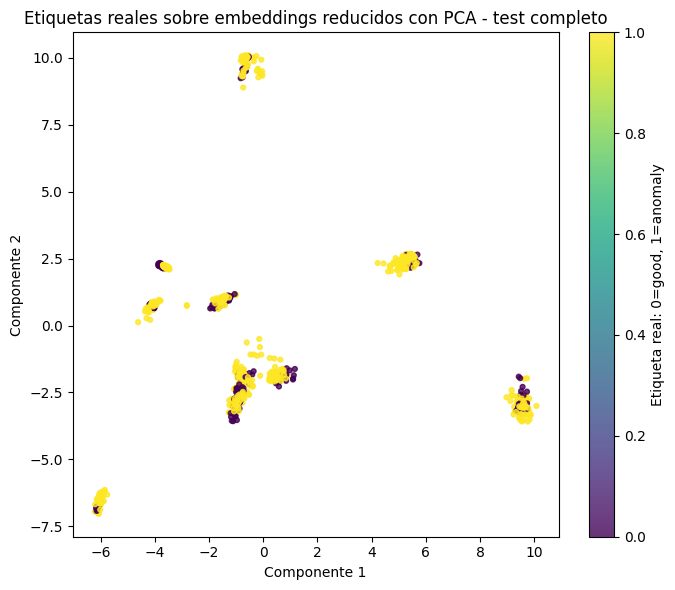

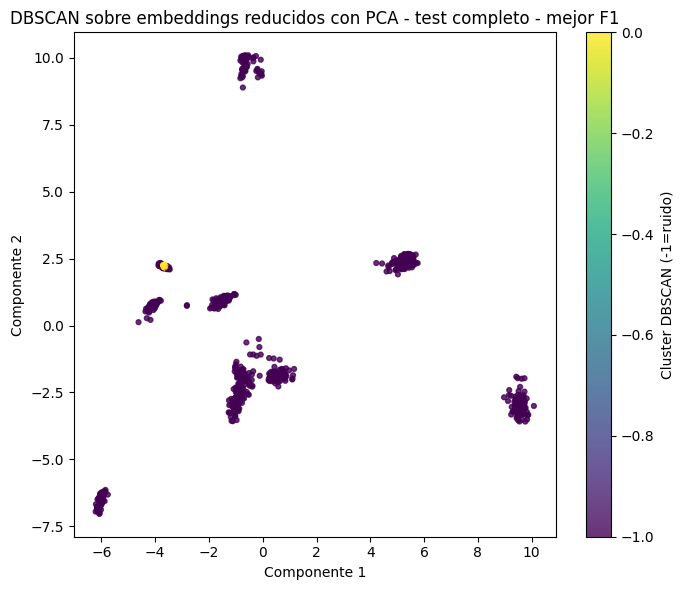

In [28]:
pca_full = run_analysis("pca", prune=False, dataset_name="test completo")


===== Análisis con TSNE - test completo =====
z_test shape: (1165, 128)
y_test shape: (1165, 2)
Distribución y_true: (array([0, 1]), array([344, 821]))

Baselines triviales:
    baseline  accuracy  precision  recall  specificity  balanced_acc       f1  pred_anomaly_rate
   todo_good  0.295279   0.000000     0.0          1.0           0.5 0.000000                0.0
todo_anomaly  0.704721   0.704721     1.0          0.0           0.5 0.826788                1.0

Mejores resultados por F1 con TSNE:
 eps  min_samples  n_clusters  n_noise  noise_rate  accuracy  precision   recall  specificity  balanced_acc       f1  pred_anomaly_rate
0.12           50           1     1094    0.939056  0.719313   0.725777 0.967113     0.127907       0.54751 0.829243           0.939056
0.03           15           1     1150    0.987124  0.709013   0.709565 0.993910     0.029070       0.51149 0.828006           0.987124
0.06           30           0     1165    1.000000  0.704721   0.704721 1.000000     0.00

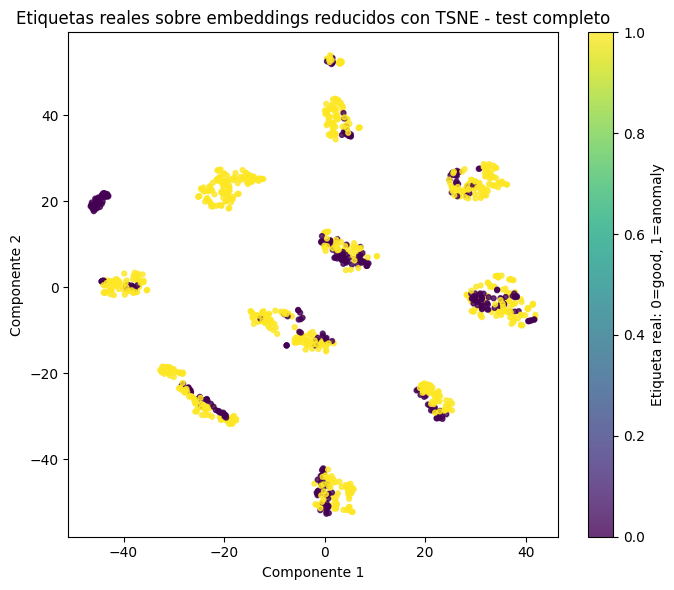

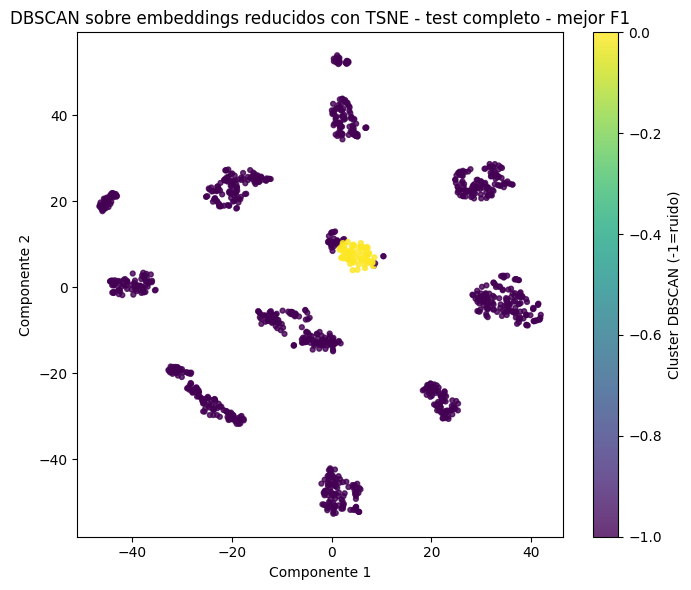

In [29]:
tsne_full = run_analysis("tsne", prune=False, dataset_name="test completo")


===== Análisis con PCA - test podado: 20% anomalías respecto a good =====
z_test shape: (413, 128)
y_test shape: (413, 2)
Distribución y_true: (array([0, 1]), array([344,  69]))

Baselines triviales:
    baseline  accuracy  precision  recall  specificity  balanced_acc       f1  pred_anomaly_rate
   todo_good   0.83293    0.00000     0.0          1.0           0.5 0.000000                0.0
todo_anomaly   0.16707    0.16707     1.0          0.0           0.5 0.286307                1.0

Mejores resultados por F1 con PCA:
 eps  min_samples  n_clusters  n_noise  noise_rate  accuracy  precision   recall  specificity  balanced_acc       f1  pred_anomaly_rate
0.03            3          12       39    0.094431  0.849879   0.589744 0.333333     0.953488      0.643411 0.425926           0.094431
0.03            5          13       46    0.111380  0.837772   0.521739 0.347826     0.936047      0.641936 0.417391           0.111380
0.02            3          20       62    0.150121  0.803874   0

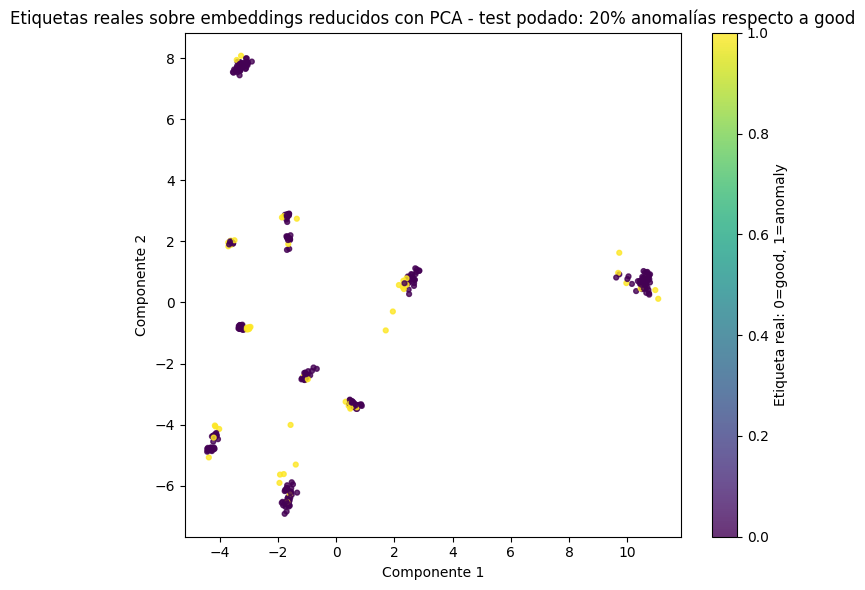

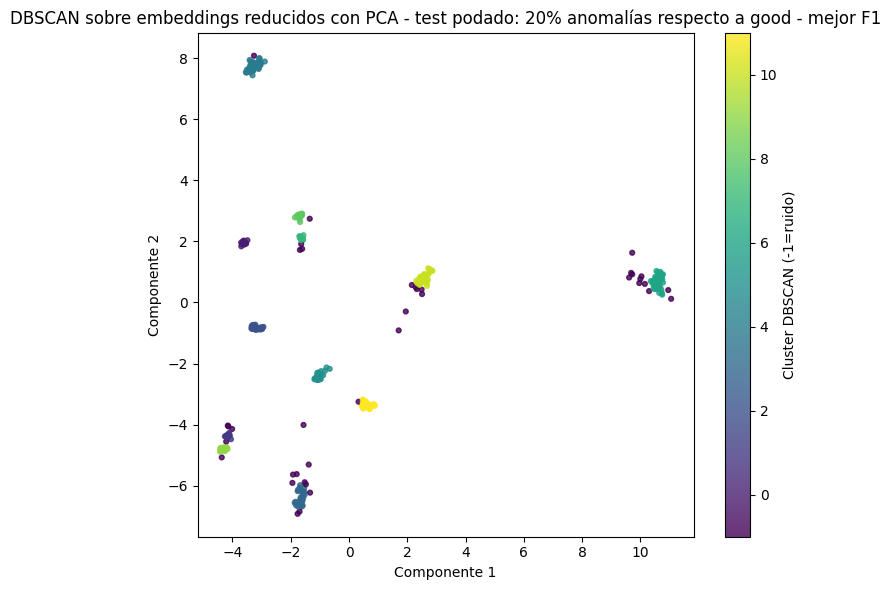

In [30]:
pca_pruned = run_analysis(
    "pca",
    prune=True,
    anomaly_to_good_ratio=0.20,
    dataset_name="test podado: 20% anomalías respecto a good",
)


===== Análisis con TSNE - test podado: 20% anomalías respecto a good =====
z_test shape: (413, 128)
y_test shape: (413, 2)
Distribución y_true: (array([0, 1]), array([344,  69]))

Baselines triviales:
    baseline  accuracy  precision  recall  specificity  balanced_acc       f1  pred_anomaly_rate
   todo_good   0.83293    0.00000     0.0          1.0           0.5 0.000000                0.0
todo_anomaly   0.16707    0.16707     1.0          0.0           0.5 0.286307                1.0

Mejores resultados por F1 con TSNE:
 eps  min_samples  n_clusters  n_noise  noise_rate  accuracy  precision   recall  specificity  balanced_acc       f1  pred_anomaly_rate
0.11           30           8       76    0.184019  0.789346   0.381579 0.420290     0.863372      0.641831 0.400000           0.184019
0.09           30           8       97    0.234867  0.757869   0.340206 0.478261     0.813953      0.646107 0.397590           0.234867
0.10           30           8       78    0.188862  0.784504  

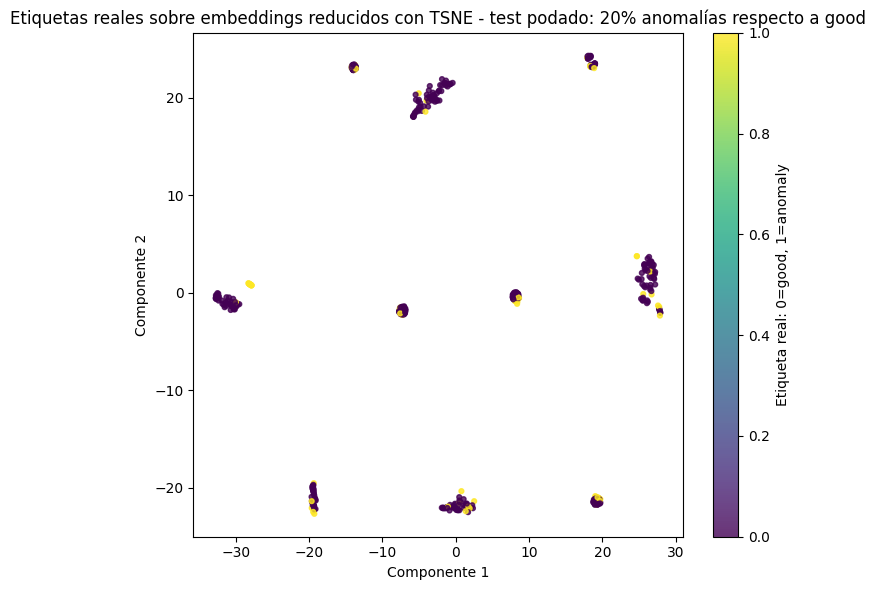

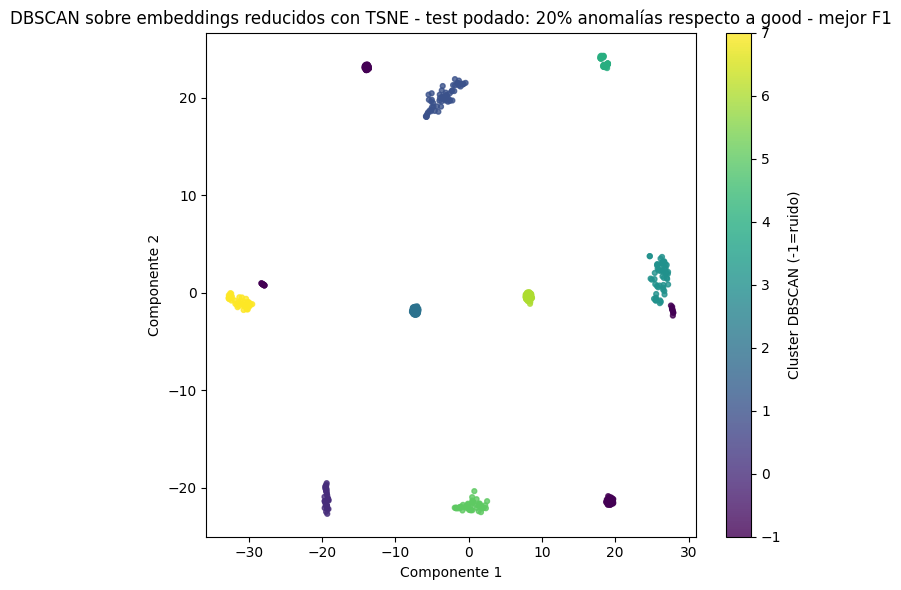

In [31]:
tsne_pruned = run_analysis(
    "tsne",
    prune=True,
    anomaly_to_good_ratio=0.20,
    dataset_name="test podado: 20% anomalías respecto a good",
)